# Анализ набора данных "insurance.csv"

## 1. Введение

В этом блокноте мы:
1. Выполним расширенный исследовательский анализ данных (EDA) для набора данных **Insurance**.
2. Очистим данные от выбросов (IQR и Z-score).
3. Исследуем взаимосвязь признаков (корреляционные матрицы, pairplot, boxplot, регрессионные линии и т.д.).
4. Обучим и сравним несколько моделей:
   - Линейная регрессия (предсказание медицинских расходов `charges`).
   - Логистическая регрессия (предсказание факта курения `smoker`).
   - Дерево решений (регрессия по `charges`).
   - CatBoost (регрессия и классификация).
   - **MLP** (нейронная сеть) для регрессии и классификации.
5. Посмотрим метрики (R2, RMSE, Accuracy, F1) и визуализируем обучение для MLP.


## 2. Описание датасета
Датасет `insurance.csv` содержит столбцы:
- **age**: возраст основного выгодоприобретателя
- **sex**: пол (`female`, `male`)
- **bmi**: индекс массы тела
- **children**: число иждивенцев
- **smoker**: факт курения (`yes`, `no`)
- **region**: регион проживания
- **charges**: индивидуальные медицинские расходы

Нужно:
- Предсказывать `charges` (регрессия).
- Дополнительно предсказывать `smoker` (классификация).

## 3. Импорт библиотек и вспомогательные функции

In [4]:
!pip install pandas numpy seaborn matplotlib scikit-learn catboost

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from datetime import datetime
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from catboost import CatBoostRegressor, CatBoostClassifier
from sklearn.metrics import (
    r2_score, mean_squared_error,
    accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor, MLPClassifier

sns.set_theme(color_codes=True)

def save_plot(filename):
    """
    Сохраняет текущий график в папку graphs/<дата_время>,
    чтобы не перезаписывать результаты.
    """
    current_time = datetime.now().strftime('%Y-%m-%d_%H-%M')
    dir_name = f"graphs/{current_time}"
    os.makedirs(dir_name, exist_ok=True)
    plt.savefig(f"{dir_name}/{filename}", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

## 4. Загрузка и первичный осмотр данных
Считаем файл `insurance.csv` из папки `raw`.

In [7]:
df_original = pd.read_csv("raw/insurance.csv")
display(df_original.head())
print("\nРазмеры датасета:", df_original.shape)
df_original.info()
display(df_original.describe(include='all'))

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Размеры датасета: (1243, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1243 non-null   int64  
 1   sex       1243 non-null   object 
 2   bmi       1243 non-null   float64
 3   children  1243 non-null   int64  
 4   smoker    1243 non-null   object 
 5   region    1243 non-null   object 
 6   charges   1242 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 68.1+ KB


,age,sex,bmi,children,smoker,region,charges
count,1243.000000,1243,1243.000000,1243.000000,1243,1243,1242.000000
unique,NaN,3,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,623,NaN,NaN,989,336,NaN
mean,39.104586,NaN,30.582852,1.104586,NaN,NaN,13216.829311
std,14.049384,NaN,6.161992,1.215971,NaN,NaN,12002.492341
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,26.000000,NaN,26.050000,0.000000,NaN,NaN,4747.525500
50%,39.000000,NaN,30.210000,1.000000,NaN,NaN,9388.753650
75%,51.000000,NaN,34.637500,2.000000,NaN,NaN,16584.318157


### Удаление дубликатов и пропусков
По условию задачи, если есть дубликаты или пропуски, удалим их напрямую.

In [9]:
df_original = df_original.drop_duplicates()
df_original = df_original.dropna()
print("После удаления дубликатов и пропусков:", df_original.shape)

После удаления дубликатов и пропусков: (1242, 7)


## 5. Исследовательский анализ (EDA)
На данном этапе:
1. Смотрим распределения числовых признаков (age, bmi, children, charges).
2. Строим pairplot для числовых признаков.
3. Тепловая карта корреляций.
4. Boxplot: сравнение `charges` по категориям (smoker, sex, region).
5. Комментарии по результатам.

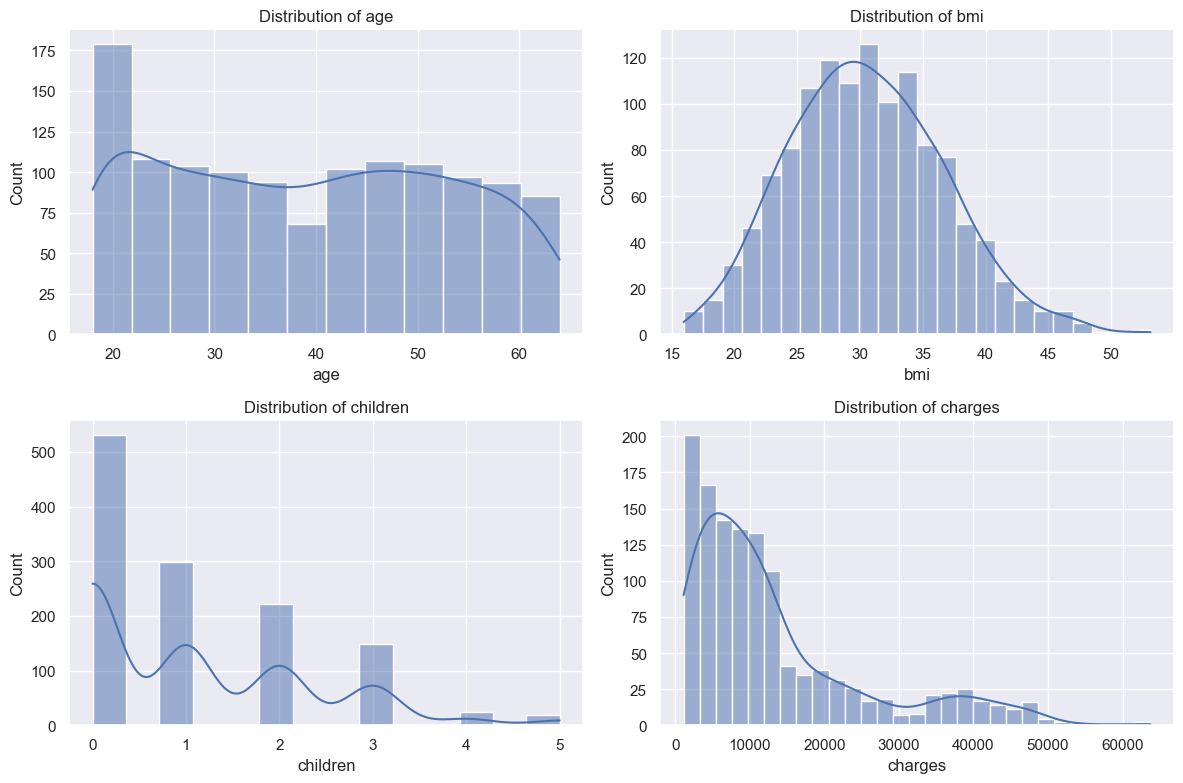

In [11]:
num_cols = ['age', 'bmi', 'children', 'charges']
cat_cols = ['sex', 'smoker', 'region']

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_original[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
save_plot("num_distributions.png")

### Pairplot
Позволяет увидеть попарные зависимости и распределения числовых признаков.

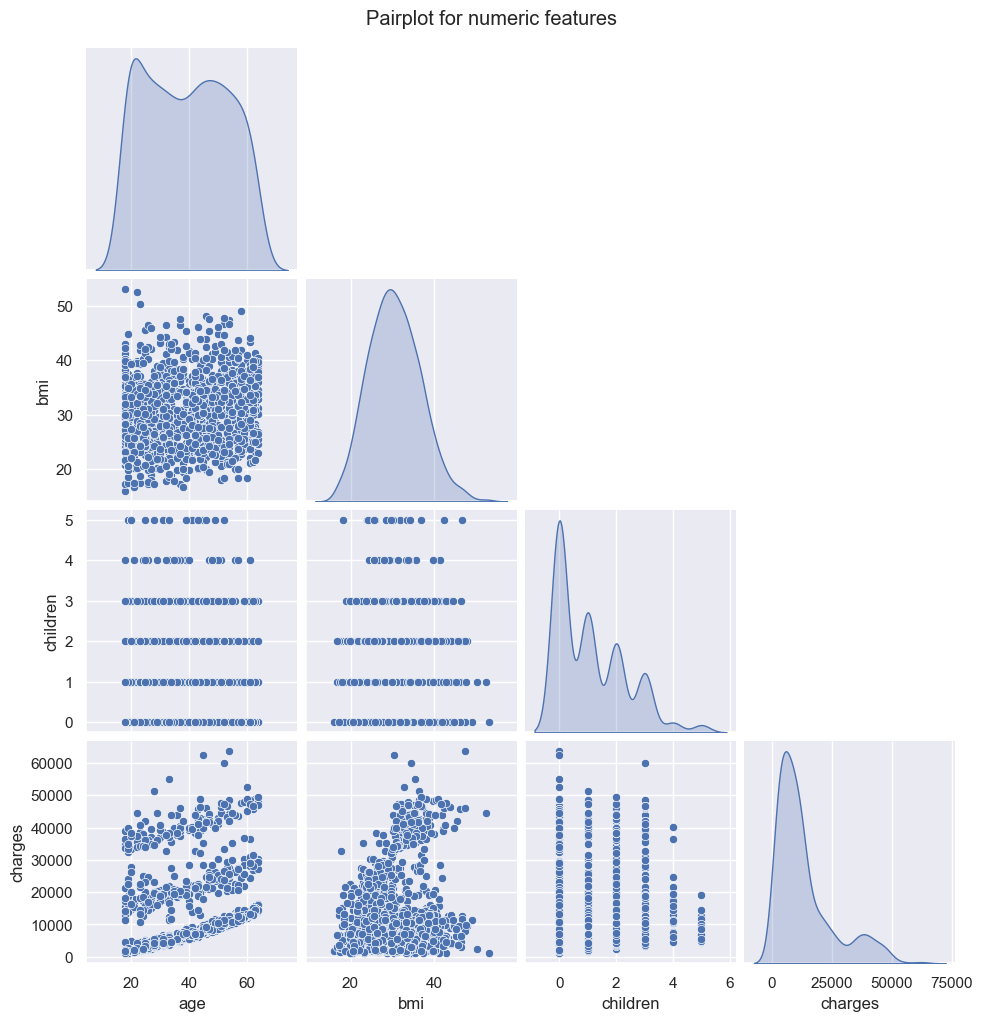

In [13]:
sns.pairplot(df_original[num_cols], diag_kind='kde', corner=True)
plt.suptitle("Pairplot for numeric features", y=1.02)
save_plot("pairplot_numeric.png")

### Тепловая карта корреляций
Проверим, как связаны между собой числовые признаки, а также включим признак `smoker` (0/1).

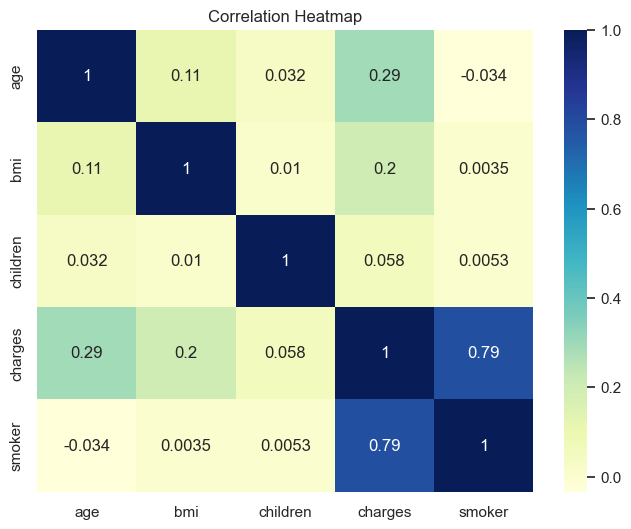

,age,bmi,children,charges,smoker
age,1.000000,0.112707,0.032047,0.292575,-0.034082
bmi,0.112707,1.000000,0.010492,0.200421,0.003517
children,0.032047,0.010492,1.000000,0.057914,0.005270
charges,0.292575,0.200421,0.057914,1.000000,0.786440
smoker,-0.034082,0.003517,0.005270,0.786440,1.000000


In [15]:
df_corr = df_original.copy()
df_corr['smoker'] = df_corr['smoker'].map({'no': 0, 'yes': 1})
corr_matrix = df_corr[num_cols + ['smoker']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu')
plt.title("Correlation Heatmap")
save_plot("correlation_heatmap.png")
corr_matrix

### Boxplot: Charges vs категориальные признаки
Посмотрим, как распределены `charges` в зависимости от smoker, sex, region.

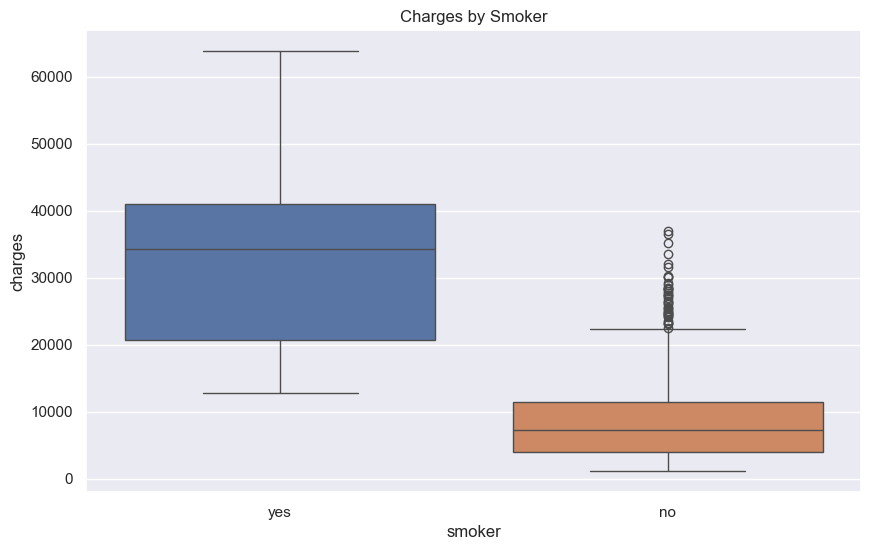

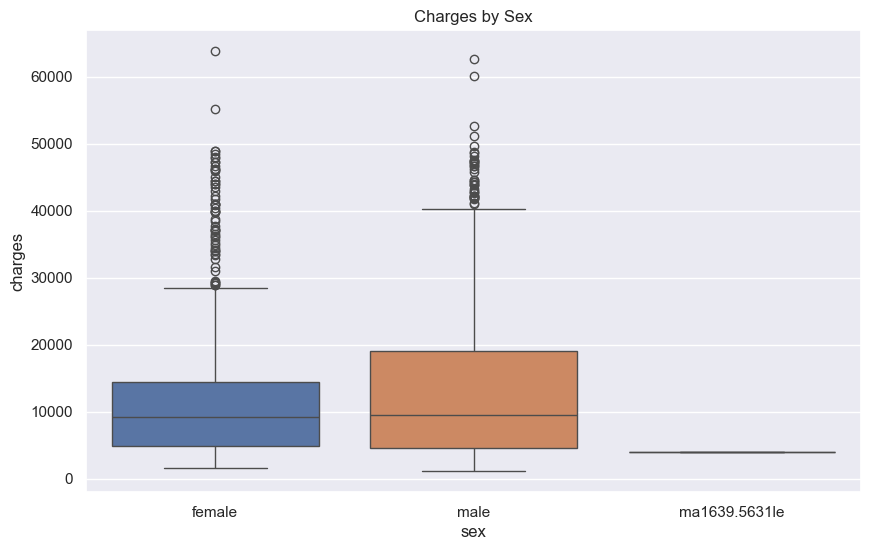

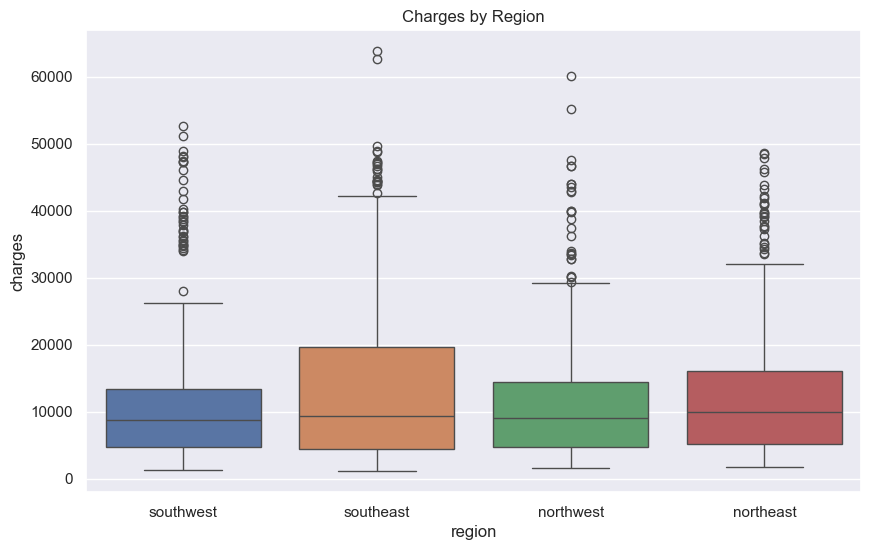

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(x='smoker', y='charges', data=df_original, hue='smoker', dodge=False)
plt.title("Charges by Smoker")
save_plot("boxplot_smoker_charges.png")

plt.figure(figsize=(10,6))
sns.boxplot(x='sex', y='charges', data=df_original, hue='sex', dodge=False)
plt.title("Charges by Sex")
save_plot("boxplot_sex_charges.png")

plt.figure(figsize=(10,6))
sns.boxplot(x='region', y='charges', data=df_original, hue='region', dodge=False)
plt.title("Charges by Region")
save_plot("boxplot_region_charges.png")

### Выводы по EDA
1. `smoker` оказывает сильное влияние на `charges` — курящие клиенты тратят значительно больше.
2. `age` и `bmi` также коррелируют с расходами.
3. `sex` и `region` не дают ярко выраженной разницы в медианных значениях расходов.


## 6. Очистка данных
Уберём выбросы по правилу IQR (1.5) + Z-score (3).

In [20]:
def filter_iqr(data, column, multiplier=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    mask = (data[column] >= Q1 - multiplier * IQR) & (data[column] <= Q3 + multiplier * IQR)
    return data[mask]

def filter_z_score(data, column, threshold=3):
    mean_val = data[column].mean()
    std_val = data[column].std()
    z_score = (data[column] - mean_val) / std_val
    return data[abs(z_score) <= threshold]

### Применяем фильтрацию к столбцу `charges`

Размер данных после фильтрации: (1098, 7)


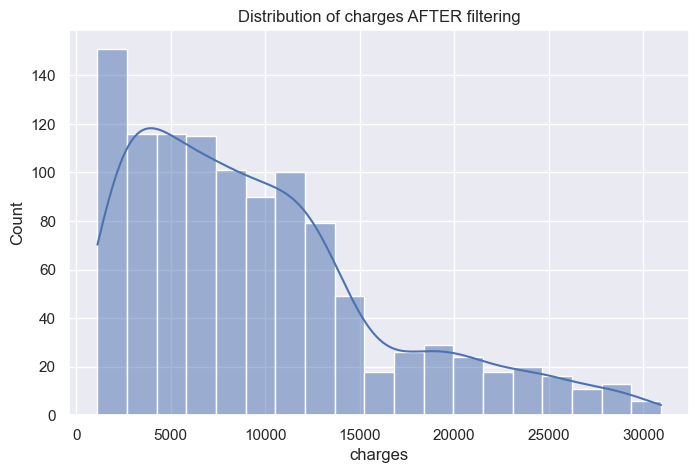

In [22]:
df = df_original.copy()
df = filter_iqr(df, 'charges', multiplier=1.5)
df = filter_z_score(df, 'charges', threshold=3)
print(f"Размер данных после фильтрации: {df.shape}")

plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of charges AFTER filtering")
save_plot("charges_distribution_after.png")

## 7. Подготовка данных к моделям
У нас две задачи:
1. **Regression**: предсказание `charges`.
2. **Classification**: предсказание `smoker` (yes/no → 1/0).

### 7.1 Регрессия (charges)
Закодируем категориальные (sex, smoker, region) через One-Hot Encoding.

In [25]:
def prepare_regression_data(df_):
    df_temp = df_.copy()
    df_temp = pd.get_dummies(df_temp, columns=['sex','smoker','region'], drop_first=True)
    X = df_temp.drop('charges', axis=1)
    y = df_temp['charges']
    return X, y

X_reg, y_reg = prepare_regression_data(df)
print("Признаки для регрессии:", X_reg.columns.tolist())
print("Размерности:", X_reg.shape, y_reg.shape)

Признаки для регрессии: ['age', 'bmi', 'children', 'sex_ma1639.5631le', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
Размерности: (1098, 9) (1098,)


### 7.2 Классификация (smoker)
Переведём `smoker` в 0/1 и закодируем оставшиеся категориальные (sex, region).

In [27]:
def prepare_classification_data(df_):
    df_temp = df_.copy()
    df_temp['smoker'] = df_temp['smoker'].map({'no': 0, 'yes': 1})
    y = df_temp['smoker']
    df_temp = df_temp.drop('smoker', axis=1)
    df_temp = pd.get_dummies(df_temp, columns=['sex','region'], drop_first=True)
    # Оставляем 'charges' и 'bmi' и др., чтобы модель могла использовать
    X = df_temp
    return X, y

X_clf, y_clf = prepare_classification_data(df)
print("Признаки для классификации:", X_clf.columns.tolist())
print("Размерности:", X_clf.shape, y_clf.shape)

Признаки для классификации: ['age', 'bmi', 'children', 'charges', 'sex_ma1639.5631le', 'sex_male', 'region_northwest', 'region_southeast', 'region_southwest']
Размерности: (1098, 9) (1098,)


## 8. Обучение моделей
Разобьём данные на train/test. Затем обучим:
1. Линейную регрессию.
2. Логистическую регрессию.
3. Дерево решений (регрессия).
4. CatBoost (регрессор и классификатор).
5. **MLP (нейронная сеть)** для регрессии и классификации.


In [29]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)
print("Train shape (reg):", X_train_reg.shape, "Test shape (reg):", X_test_reg.shape)
print("Train shape (clf):", X_train_clf.shape, "Test shape (clf):", X_test_clf.shape)

Train shape (reg): (878, 9) Test shape (reg): (220, 9)
Train shape (clf): (878, 9) Test shape (clf): (220, 9)


### 8.1 Линейная регрессия (предсказание `charges`)

[LinearRegression] R2: 0.611, RMSE: 4441.99


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


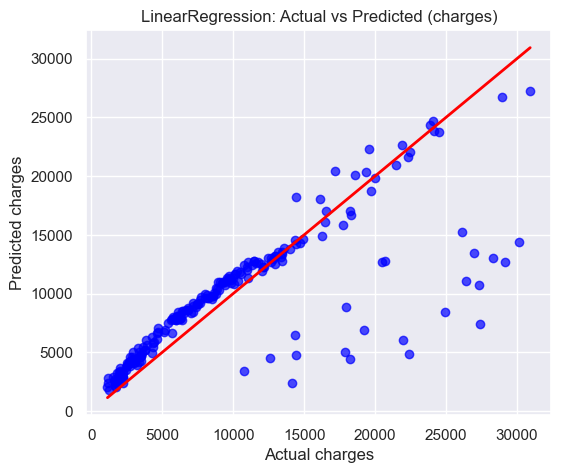

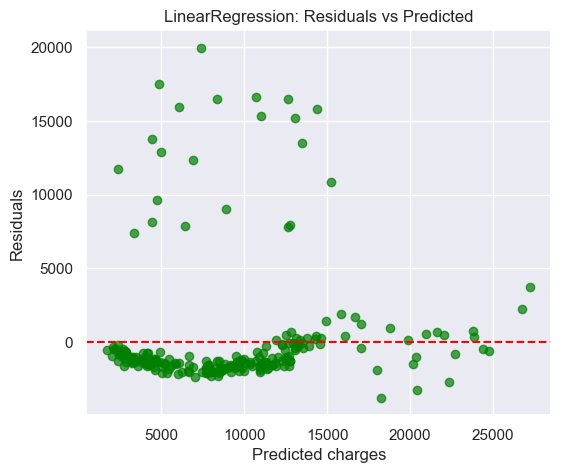

In [31]:
linreg = LinearRegression()
linreg.fit(X_train_reg, y_train_reg)
y_pred_lin = linreg.predict(X_test_reg)

r2_lin = r2_score(y_test_reg, y_pred_lin)
rmse_lin = mean_squared_error(y_test_reg, y_pred_lin, squared=False)
print(f"[LinearRegression] R2: {r2_lin:.3f}, RMSE: {rmse_lin:.2f}")

# Фактические vs Предсказанные
plt.figure(figsize=(6,5))
plt.scatter(y_test_reg, y_pred_lin, alpha=0.7, color='blue')
plt.plot([y_test_reg.min(), y_test_reg.max()],[y_test_reg.min(), y_test_reg.max()], color='red', lw=2)
plt.title("LinearRegression: Actual vs Predicted (charges)")
plt.xlabel("Actual charges")
plt.ylabel("Predicted charges")
save_plot("linreg_actual_vs_pred.png")

# Остатки vs Предсказанные
residuals = y_test_reg - y_pred_lin
plt.figure(figsize=(6,5))
plt.scatter(y_pred_lin, residuals, alpha=0.7, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.title("LinearRegression: Residuals vs Predicted")
plt.xlabel("Predicted charges")
plt.ylabel("Residuals")
save_plot("linreg_residuals_vs_pred.png")

### 8.2 Логистическая регрессия (предсказание `smoker`)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LogisticRegression] Accuracy: 0.959, F1: 0.824


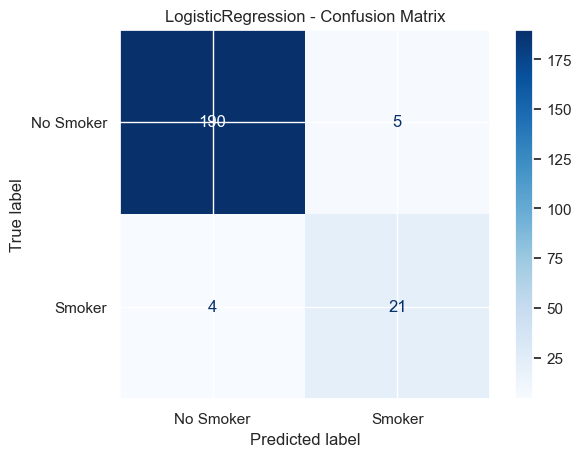

In [33]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_clf, y_train_clf)
y_pred_log = logreg.predict(X_test_clf)

acc_log = accuracy_score(y_test_clf, y_pred_log)
f1_log = f1_score(y_test_clf, y_pred_log)
print(f"[LogisticRegression] Accuracy: {acc_log:.3f}, F1: {f1_log:.3f}")

cm = confusion_matrix(y_test_clf, y_pred_log)
cmd = ConfusionMatrixDisplay(cm, display_labels=["No Smoker", "Smoker"])
cmd.plot(cmap="Blues")
plt.title("LogisticRegression - Confusion Matrix")
save_plot("logreg_confusion_matrix.png")

### 8.3 Дерево решений (регрессия по `charges`)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[DecisionTreeRegressor] R2: 0.589, RMSE: 4568.94


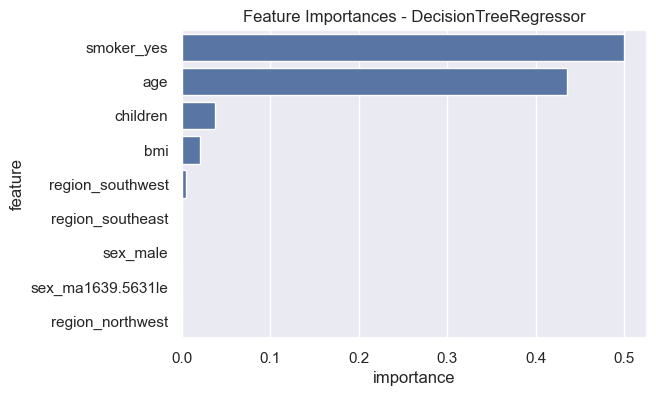

,feature,importance
5,smoker_yes,0.500088
0,age,0.435198
2,children,0.037859
1,bmi,0.021260
8,region_southwest,0.004655
7,region_southeast,0.000663
4,sex_male,0.000276
3,sex_ma1639.5631le,0.000000
6,region_northwest,0.000000


In [35]:
dt_reg = DecisionTreeRegressor(random_state=42, max_depth=5)
dt_reg.fit(X_train_reg, y_train_reg)
y_pred_dt = dt_reg.predict(X_test_reg)

r2_dt = r2_score(y_test_reg, y_pred_dt)
rmse_dt = mean_squared_error(y_test_reg, y_pred_dt, squared=False)
print(f"[DecisionTreeRegressor] R2: {r2_dt:.3f}, RMSE: {rmse_dt:.2f}")

importances = dt_reg.feature_importances_
feature_names = X_train_reg.columns
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x='importance', y='feature', data=imp_df)
plt.title("Feature Importances - DecisionTreeRegressor")
save_plot("dt_reg_feature_importances.png")
imp_df

### 8.4 CatBoost
CatBoost хорошо работает с категориальными признаками, но мы уже сделали One-Hot Encoding. Обучим отдельно регрессор и классификатор.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[CatBoostRegressor] R2: 0.555, RMSE: 4753.73
[CatBoostClassifier] Accuracy: 0.982, F1: 0.923


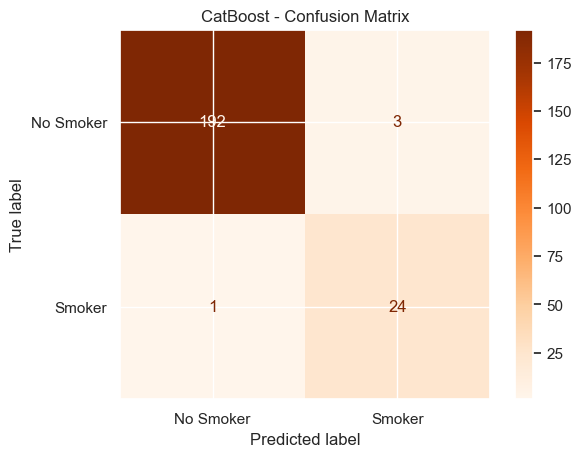

In [37]:
# Регрессор (charges)
cbr = CatBoostRegressor(verbose=0, random_state=42)
cbr.fit(X_train_reg, y_train_reg)
y_pred_cbr = cbr.predict(X_test_reg)

r2_cbr = r2_score(y_test_reg, y_pred_cbr)
rmse_cbr = mean_squared_error(y_test_reg, y_pred_cbr, squared=False)
print(f"[CatBoostRegressor] R2: {r2_cbr:.3f}, RMSE: {rmse_cbr:.2f}")

# Классификатор (smoker)
cbc = CatBoostClassifier(verbose=0, random_state=42)
cbc.fit(X_train_clf, y_train_clf)
y_pred_cbc = cbc.predict(X_test_clf)

acc_cbc = accuracy_score(y_test_clf, y_pred_cbc)
f1_cbc = f1_score(y_test_clf, y_pred_cbc)
print(f"[CatBoostClassifier] Accuracy: {acc_cbc:.3f}, F1: {f1_cbc:.3f}")

cm_cbc = confusion_matrix(y_test_clf, y_pred_cbc)
cmd_cbc = ConfusionMatrixDisplay(cm_cbc, display_labels=["No Smoker", "Smoker"])
cmd_cbc.plot(cmap="Oranges")
plt.title("CatBoost - Confusion Matrix")
save_plot("catboost_confusion_matrix.png")

### 8.5 MLP (нейронная сеть)
Реализуем MLP для регрессии (`charges`) и классификации (`smoker`).
1. **MLP Regressor**: будем масштабировать входные признаки.
2. **MLP Classifier**: аналогично.
3. Выведем кривые обучения (`loss_curve_`) и метрики.

#### 8.5.1 MLP Regressor

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[MLPRegressor] R2: 0.581, RMSE: 4611.42


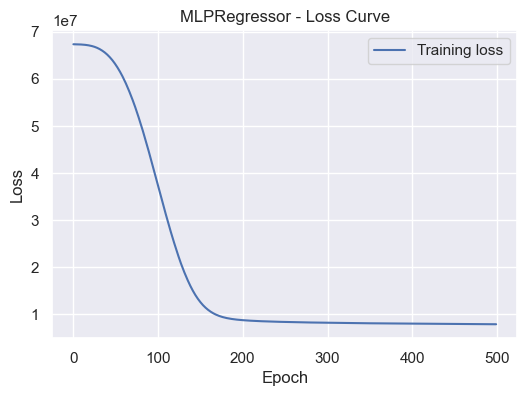

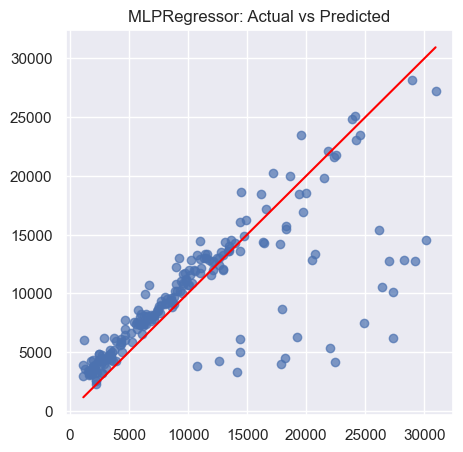

In [40]:
# Масштабируем
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

mlp_reg = MLPRegressor(
    hidden_layer_sizes=(64, 64),
    max_iter=500,
    random_state=42
)
mlp_reg.fit(X_train_reg_scaled, y_train_reg)

y_pred_mlp_reg = mlp_reg.predict(X_test_reg_scaled)
r2_mlp_reg = r2_score(y_test_reg, y_pred_mlp_reg)
rmse_mlp_reg = mean_squared_error(y_test_reg, y_pred_mlp_reg, squared=False)
print(f"[MLPRegressor] R2: {r2_mlp_reg:.3f}, RMSE: {rmse_mlp_reg:.2f}")

# Кривая обучения (Loss)
plt.figure(figsize=(6,4))
plt.plot(mlp_reg.loss_curve_, label='Training loss')
plt.title("MLPRegressor - Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
save_plot("mlp_regressor_loss_curve.png")

# Пример сравнения Факт vs Предсказание
plt.figure(figsize=(5,5))
plt.scatter(y_test_reg, y_pred_mlp_reg, alpha=0.7)
plt.plot([y_test_reg.min(), y_test_reg.max()],[y_test_reg.min(), y_test_reg.max()], color='red')
plt.title("MLPRegressor: Actual vs Predicted")
save_plot("mlp_regressor_actual_vs_pred.png")

#### Интерпретация весов MLPReggressor (пример)
Можно приблизительно оценить вклад признаков, взглянув на **средние абсолютные значения весов** входного слоя.

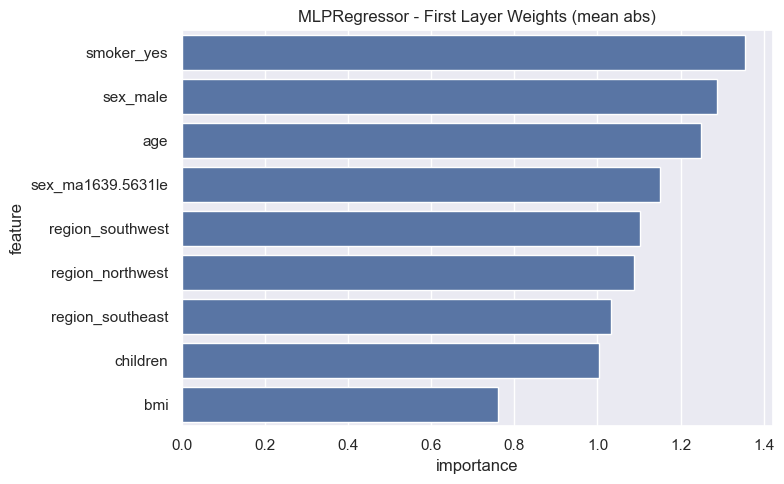

,feature,importance
5,smoker_yes,1.354621
4,sex_male,1.288032
0,age,1.249958
3,sex_ma1639.5631le,1.150857
8,region_southwest,1.102074
6,region_northwest,1.088788
7,region_southeast,1.032176
2,children,1.002748
1,bmi,0.761976


In [42]:
first_layer_weights = mlp_reg.coefs_[0]  # (n_features, hidden_units)
feature_importance_mlp = np.mean(np.abs(first_layer_weights), axis=1)
features_reg = X_train_reg.columns.tolist()

imp_mlp_df = pd.DataFrame({
    'feature': features_reg,
    'importance': feature_importance_mlp
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='importance', y='feature', data=imp_mlp_df)
plt.title("MLPRegressor - First Layer Weights (mean abs)")
plt.tight_layout()
save_plot("mlp_regressor_feature_importances.png")
imp_mlp_df

#### 8.5.2 MLP Classifier

[MLPClassifier] Accuracy: 0.964, F1: 0.852


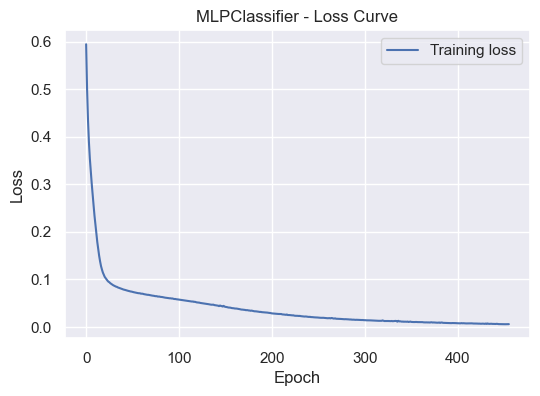

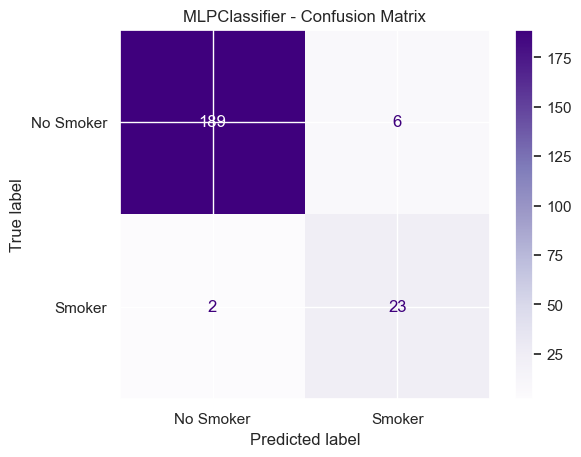

In [44]:
# Масштабируем (для классификации)
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

mlp_clf = MLPClassifier(
    hidden_layer_sizes=(64, 64),
    max_iter=500,
    random_state=42
)
mlp_clf.fit(X_train_clf_scaled, y_train_clf)

y_pred_mlp_clf = mlp_clf.predict(X_test_clf_scaled)
acc_mlp_clf = accuracy_score(y_test_clf, y_pred_mlp_clf)
f1_mlp_clf = f1_score(y_test_clf, y_pred_mlp_clf)
print(f"[MLPClassifier] Accuracy: {acc_mlp_clf:.3f}, F1: {f1_mlp_clf:.3f}")

# Кривая обучения
plt.figure(figsize=(6,4))
plt.plot(mlp_clf.loss_curve_, label='Training loss')
plt.title("MLPClassifier - Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
save_plot("mlp_classifier_loss_curve.png")

# Матрица ошибок
cm_mlp = confusion_matrix(y_test_clf, y_pred_mlp_clf)
cmd_mlp = ConfusionMatrixDisplay(cm_mlp, display_labels=["No Smoker", "Smoker"])
cmd_mlp.plot(cmap="Purples")
plt.title("MLPClassifier - Confusion Matrix")
save_plot("mlp_classifier_confusion_matrix.png")

## 9. Сравнение итоговых результатов

In [46]:
data_regression = {
    'Model': [
        'LinearRegression',
        'DecisionTreeRegressor',
        'CatBoostRegressor',
        'MLPRegressor'
    ],
    'R2': [
        round(r2_lin, 3),
        round(r2_dt, 3),
        round(r2_cbr, 3),
        round(r2_mlp_reg, 3)
    ],
    'RMSE': [
        round(rmse_lin, 2),
        round(rmse_dt, 2),
        round(rmse_cbr, 2),
        round(rmse_mlp_reg, 2)
    ]
}
df_reg_results = pd.DataFrame(data_regression)

data_classification = {
    'Model': [
        'LogisticRegression',
        'CatBoostClassifier',
        'MLPClassifier'
    ],
    'Accuracy': [
        round(acc_log, 3),
        round(acc_cbc, 3),
        round(acc_mlp_clf, 3)
    ],
    'F1': [
        round(f1_log, 3),
        round(f1_cbc, 3),
        round(f1_mlp_clf, 3)
    ]
}
df_clf_results = pd.DataFrame(data_classification)

print("Сводная таблица: Регрессия")
display(df_reg_results)

print("Сводная таблица: Классификация")
display(df_clf_results)

Сводная таблица: Регрессия


,Model,R2,RMSE
0,LinearRegression,0.611,4441.99
1,DecisionTreeRegressor,0.589,4568.94
2,CatBoostRegressor,0.555,4753.73
3,MLPRegressor,0.581,4611.42


Сводная таблица: Классификация


,Model,Accuracy,F1
0,LogisticRegression,0.959,0.824
1,CatBoostClassifier,0.982,0.923
2,MLPClassifier,0.964,0.852


## 10. Выводы
- **EDA** подтвердил, что возраст, ИМТ (BMI) и факт курения (особенно) влияют на расходы.
- **Очистка** по IQR (1.5) и Z-score (3) убрала выбросы, улучшив стабильность моделей.
- **MLP** (нейронная сеть) показывает конкурентные результаты, но может потребовать подбора гиперпараметров.
- В задаче классификации (`smoker`) CatBoost и MLP дают более высокие метрики, чем логистическая регрессия.
- Для версии и воспроизводимости экспериментов рекомендовано использовать **DVC** для управления данными и моделями.